In [2]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_MPC_VS_PD_dir = os.getcwd()
internal_april_25_dir = os.path.abspath(os.path.join(internal_MPC_VS_PD_dir, '..'))
internal_MPC_data_dir = os.path.abspath(os.path.join(internal_april_25_dir, 'MPC_test_data'))
internal_PDC_data_dir = os.path.abspath(os.path.join(internal_april_25_dir, 'PD_test_data'))
internal_VTR_dir = os.path.abspath(os.path.join(internal_MPC_VS_PD_dir, '..', '..'))
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

In [3]:
internal_PDC_CDP_data_dir = os.path.abspath(os.path.join(internal_PDC_data_dir, 'Collected_Data_Python'))
internal_MPC_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Collected_Data_Python'))
print(f'The PDC data directory : {internal_PDC_CDP_data_dir}')
print(f'The MPC data directory : {internal_MPC_CDP_data_dir}')

The PDC data directory : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\April_25\PD_test_data\Collected_Data_Python
The MPC data directory : d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\April_25\MPC_test_data\Collected_Data_Python


In [4]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_CDP_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, os.listdir(internal_PDC_CDP_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_CDP_data_dir))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, os.listdir(internal_MPC_CDP_data_dir)[i])))

In [5]:
print(len(PDC_data_list))
print(len(MPC_data_list))

2
3


In [8]:
def plot(store_times, store_velocities, store_seperations, Dr = CP.Dr_3, Vp = CP.Vp_3):
    fig, axes = plt.subplots(1, 2, figsize = (60, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(2):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness
    
    store_seperations[0] = [Dr - x for x in store_seperations[0]]
    store_seperations[1] = [Dr - x for x in store_seperations[1]]

    axes[0].plot(store_times[0], store_seperations[0], label = f'PD_Controller', color = 'purple', linewidth = 4)
    axes[0].plot(store_times[1], store_seperations[1], label = f'MCP_Controller', color = 'blue', linewidth = 4)
    #axes[0].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (PD)', linewidth = 4)
    #axes[0].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (PD)', linewidth = 4)
    #axes[0].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (MPC)', linewidth = 4)
    #axes[0].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (MPC)', linewidth = 4)
    axes[0].plot(store_times[0], [CP.Dd + CP.Td * Vp for _ in range(len(store_seperations[0]))], label = f'Desired final seperation', color = 'green', linewidth = 6)
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Seperation [m]', fontsize = font, fontweight = 'bold')
    axes[0].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(store_times[0], store_velocities[0], label = f'PD_Controller', color = 'purple', linewidth = 4)
    axes[1].plot(store_times[1], store_velocities[1], label = f'MPC_Controller', color = 'blue', linewidth = 4)
    #axes[1].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (PD)', linewidth = 4)
    #axes[1].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (PD)', linewidth = 4)
    #axes[1].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (MPC)', linewidth = 4)
    #axes[1].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (MPC)', linewidth = 4)
    axes[1].plot(store_times[0], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))], label = f'Desired final velocity', color = 'green', linewidth = 4)
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    axes[1].set_title(f'[Dr = {Dr}m , Vp = {round(Vp * 18 / 5, 2)}km/hr', fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    plt.show()

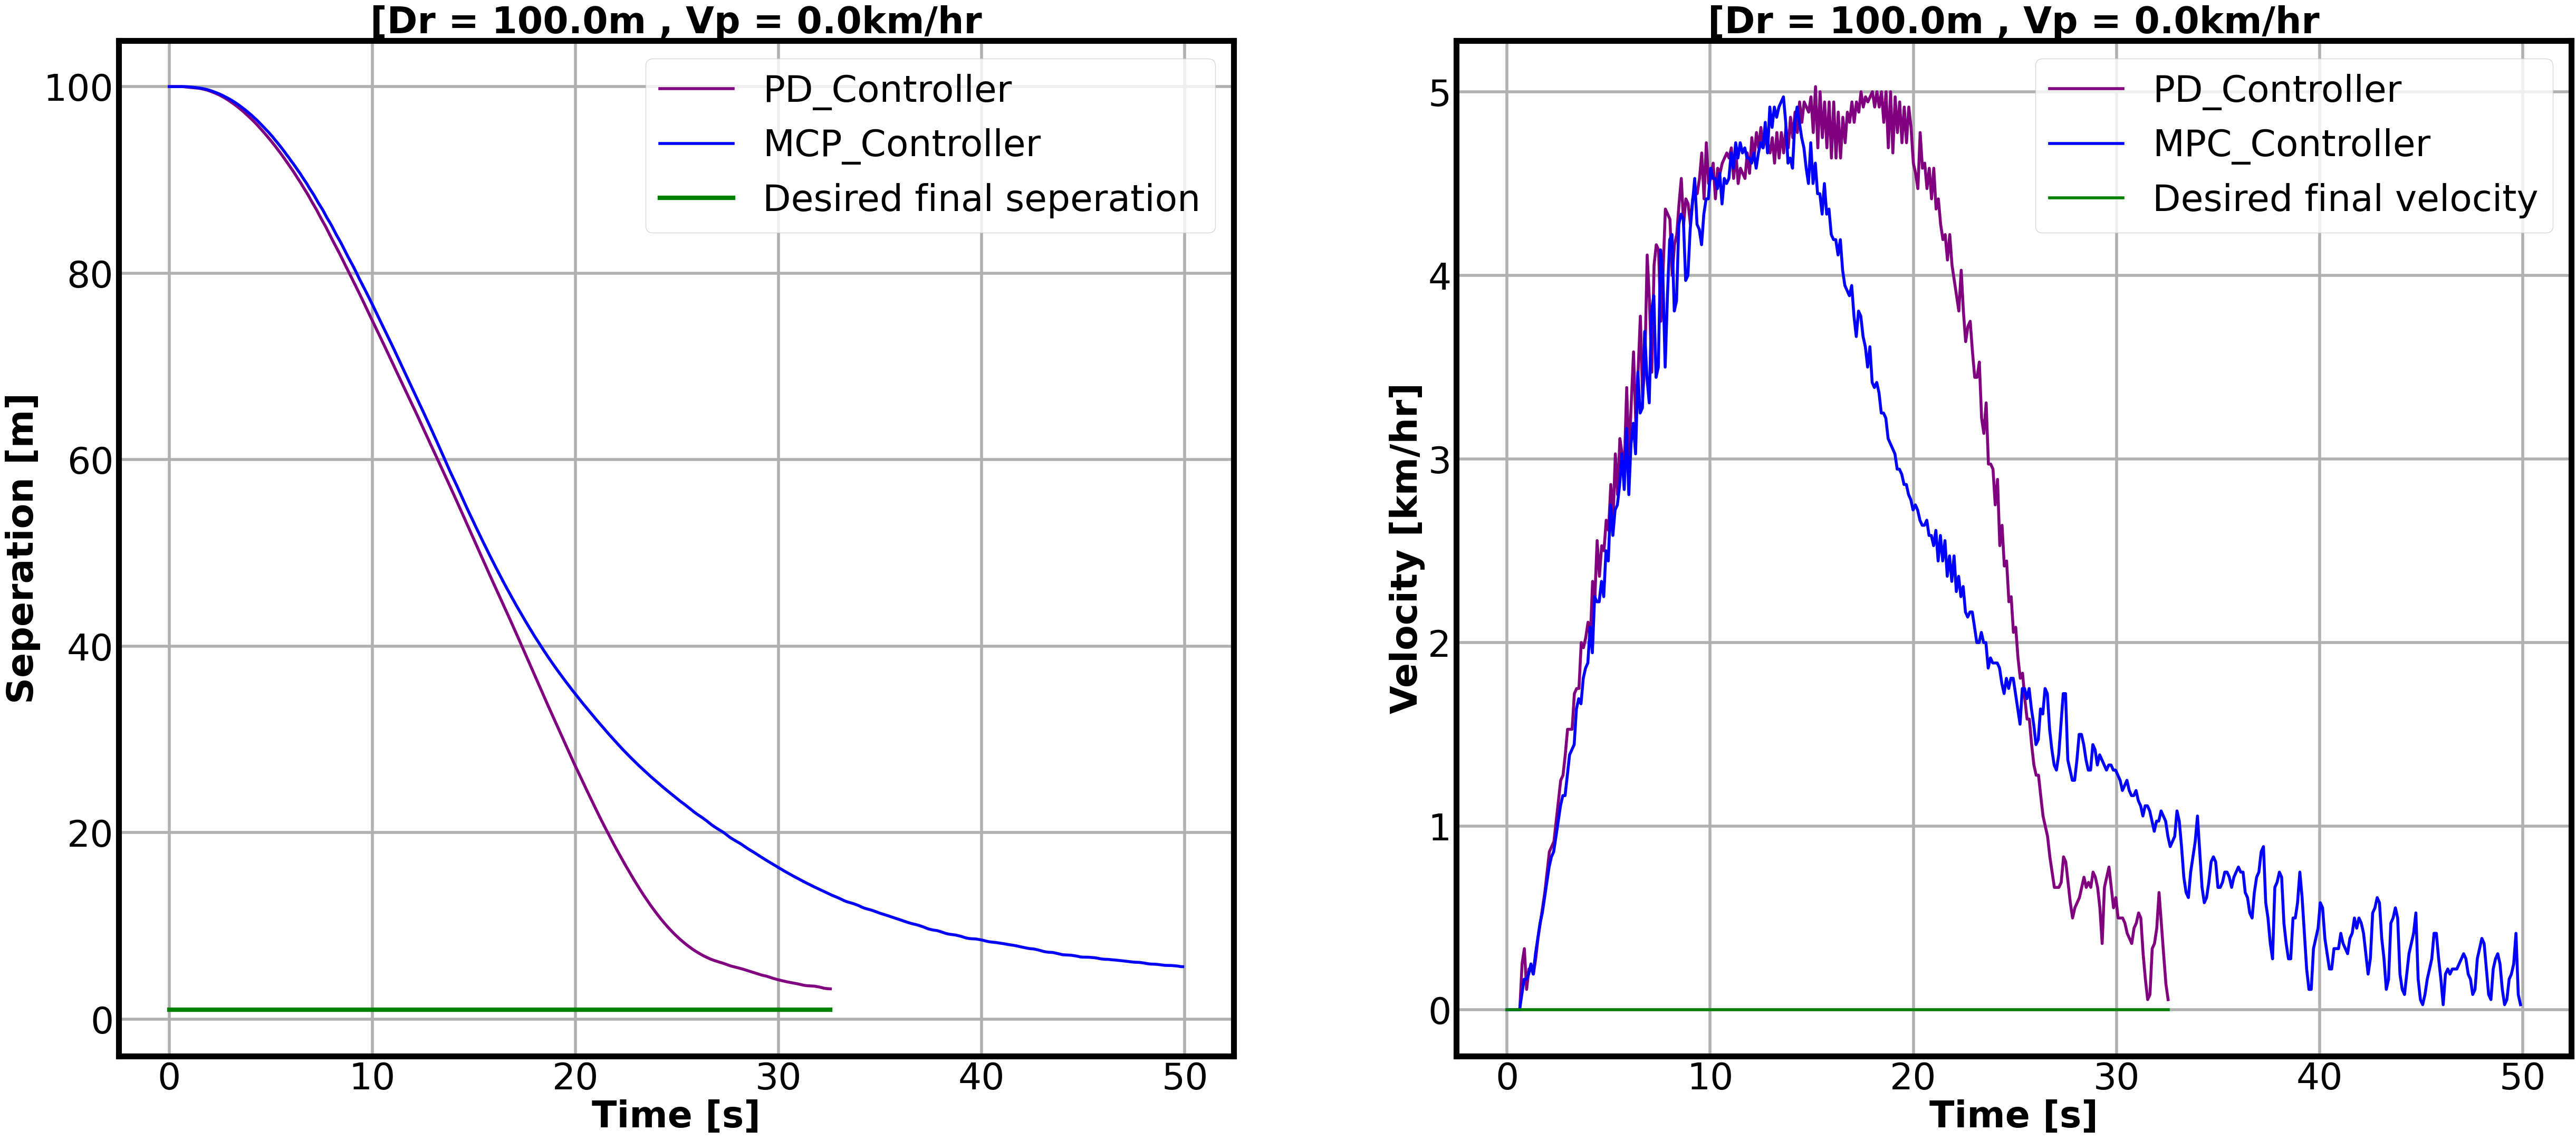

In [10]:
plot([list(PDC_data_list[0]['Time(s)']), list(MPC_data_list[-1]['Time(s)'])], [list(PDC_data_list[0]['Ego_Velocity(m/s)']), list(MPC_data_list[-1]['Ego_Velocity(m/s)'])], [list(PDC_data_list[0]['Ego_Position(m)']), list(MPC_data_list[-1]['Ego_Position(m)'])])